In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


## Exercice 4 : impact et detection d'outliers



b_0=6.188115226767572 et b_1=5.582565611245956


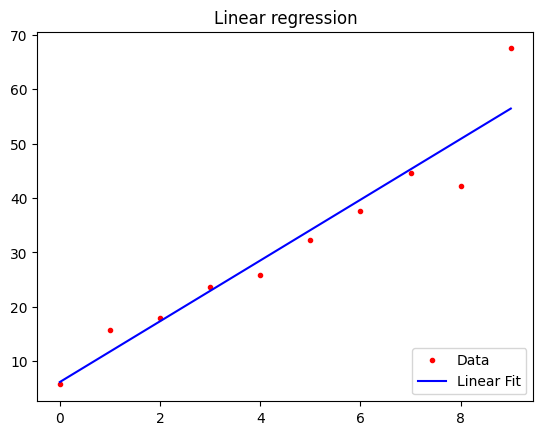

In [35]:
#generation de donnees test
def generate_data(n_samples, outlier=False, b_1=4.):
    x = np.arange(n_samples)
    y = 10. + b_1*x + np.random.randn(n_samples)*3.
    if outlier:
        y[-1] += 20
    return x, y

def s2(y_true, y_pred):
    n = len(y_true)
    SSE = np.sum((y_true - y_pred)**2)
    return SSE / (n-1)


x, y = generate_data(n_samples=10, outlier=True)
# instanciation de sklearn.linear_model.LinearRegression
lr = LinearRegression()
lr.fit(x[:, np.newaxis], y)  # np.newaxis est utilise car x doit etre une matrice 2d avec 'LinearRegression'

# representation du resultat

print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0]))

fig = plt.figure()
plt.plot(x, y, 'r.')
plt.plot(x, lr.predict(x[:, np.newaxis]), 'b-')
plt.legend(('Data', 'Linear Fit'), loc='lower right')
plt.title('Linear regression')
plt.show()


### <span style="color:blue">QUESTION 4.1 :</span> 


Remarquons que la ligne 'y[9]=y[9]+20' génere artificiellement une donnée aberrante.

Tester l'impact de la donnée aberrante en estimant b_0, b_1 et s^2 sur 
- 5 jeux de données générés comme dans la cellule précédente et
- 5 autres jeux aussi générés suivant cette méthode, mais sans la données aberrant (simplement ne pas executer la ligne y[9]=y[9]+20).

On remarque que $\beta_0 = 10$, $\beta_1 = 4$ et $\sigma=3$ dans les données simulees.


### <span style="color:blue">REPONSE 4.1 :</span> 



b_0=8.1691672908504 et b_1=4.88134597339107 et R^2=0.8905354794673269, s^2=26.84805146924953


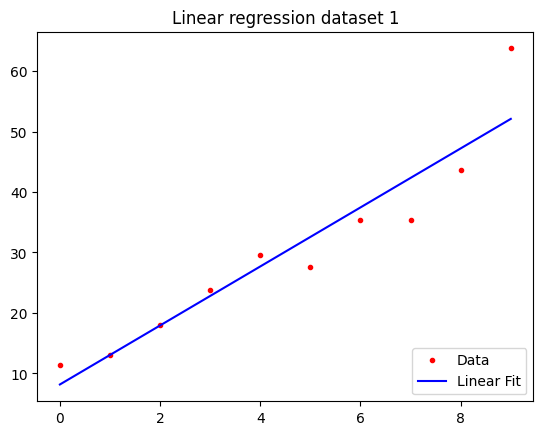

b_0=5.163300556091432 et b_1=5.366978732407498 et R^2=0.8860457747528407, s^2=33.95826253803713


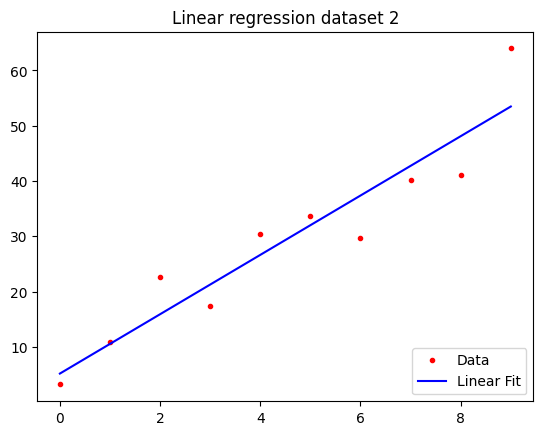

b_0=8.916312692996183 et b_1=4.982667378167514 et R^2=0.8139926354686994, s^2=52.00497546705012


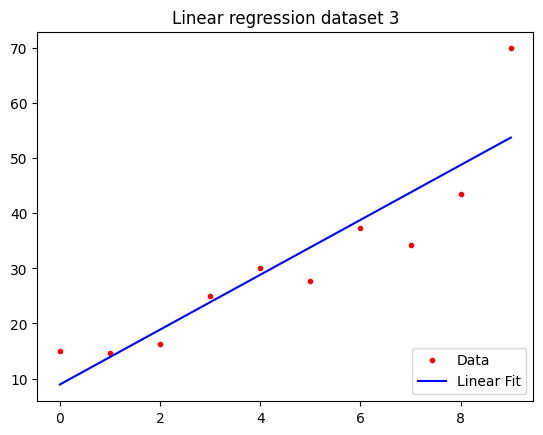

b_0=7.0091405038262025 et b_1=5.174200842961771 et R^2=0.8751211230177647, s^2=35.02021610719264


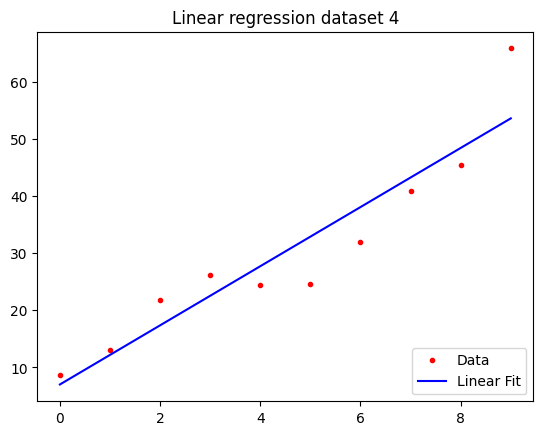

b_0=5.694496038502642 et b_1=5.410065521729336 et R^2=0.9183167231112129, s^2=23.86476421111856


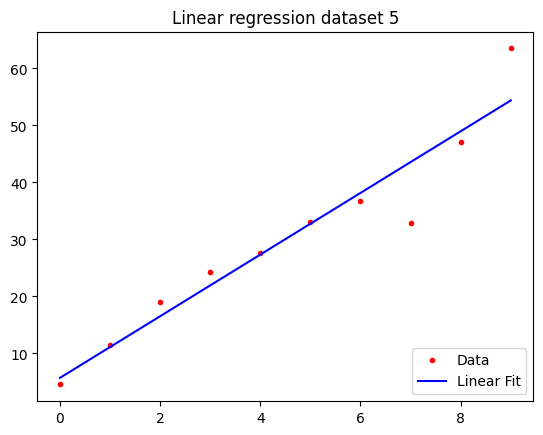

b_0=8.903149908728452 et b_1=4.137873428563029 et R^2=0.9872891116972787, s^2=2.020679326593529


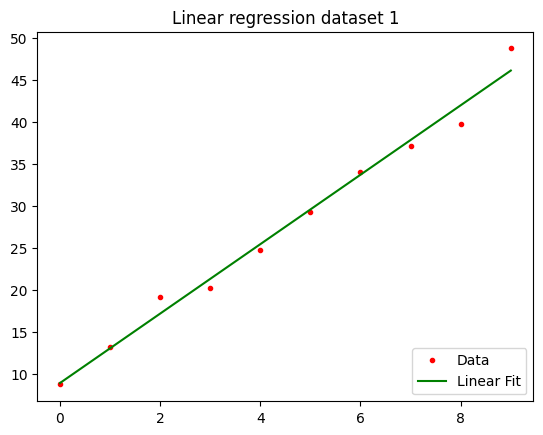

b_0=9.997065315837666 et b_1=3.8917205647768647 et R^2=0.9597966552573419, s^2=5.815374550344716


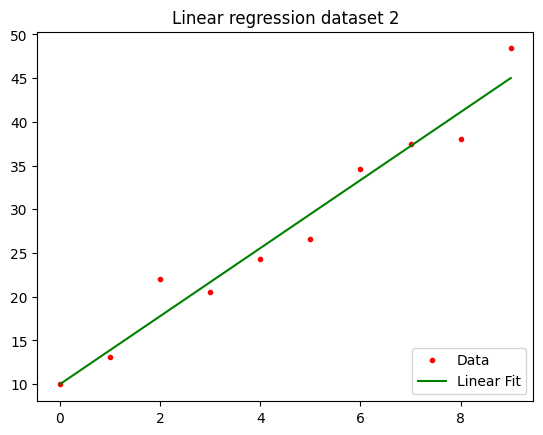

b_0=9.803174425263752 et b_1=4.135544462941536 et R^2=0.9445064601069314, s^2=9.211159962033681


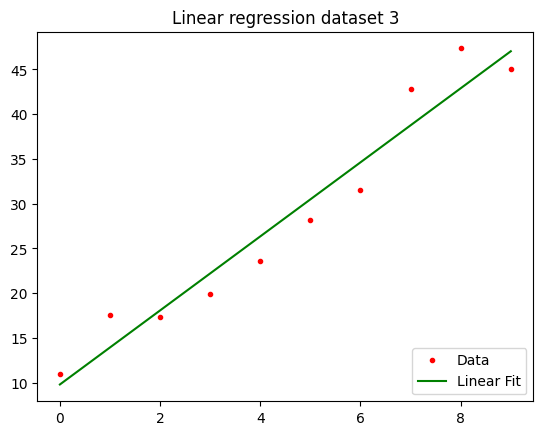

b_0=11.559177913340243 et b_1=3.513544048004706 et R^2=0.9375452953103753, s^2=7.538329984979136


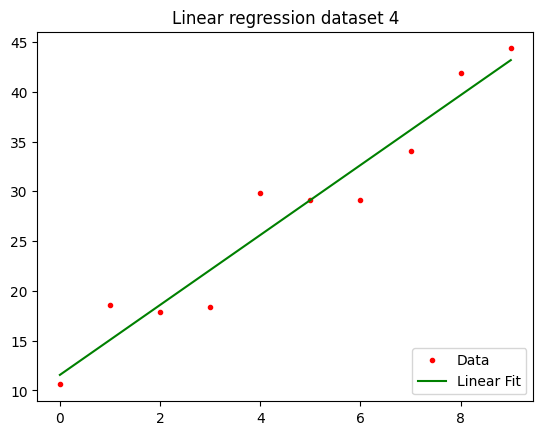

b_0=12.691651756198283 et b_1=3.5709464078813453 et R^2=0.9671195503575705, s^2=3.974071616387164


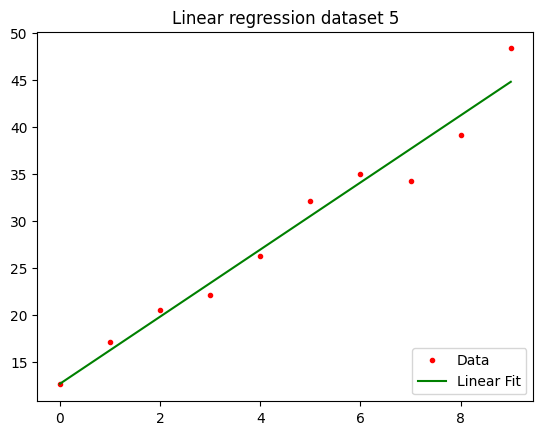

In [8]:
#5 jeux de données avec outliers
x1, y1 = generate_data(n_samples=10, outlier=True)
x2, y2 = generate_data(n_samples=10, outlier=True)  
x3, y3 = generate_data(n_samples=10, outlier=True)
x4, y4 = generate_data(n_samples=10, outlier=True)
x5, y5 = generate_data(n_samples=10, outlier=True)

list_x = [x1, x2, x3, x4, x5]
list_y = [y1, y2, y3, y4, y5]

lr = LinearRegression()
for i in range(5):
    lr.fit(list_x[i][:, np.newaxis], list_y[i])
    s_squared = 1/(len(list_y[i])-1) * np.sum((list_y[i]-lr.predict(list_x[i][:, np.newaxis]))**2) #calcul de s2
    R_squared = lr.score(list_x[i][:, np.newaxis], list_y[i]) #calcul de R2
    print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0])+' et R^2='+str(R_squared)+', s^2='+str(s_squared))
    fig = plt.figure()
    plt.plot(list_x[i], list_y[i], 'r.')
    plt.plot(list_x[i], lr.predict(list_x[i][:, np.newaxis]), 'b-')
    plt.legend(('Data', 'Linear Fit'), loc='lower right')
    plt.title('Linear regression dataset '+str(i+1))
    plt.show()

#5 jeux de données sans outliers
x11, y11 = generate_data(n_samples=10, outlier=False)
x12, y12 = generate_data(n_samples=10, outlier=False)  
x13, y13 = generate_data(n_samples=10, outlier=False)
x14, y14 = generate_data(n_samples=10, outlier=False)
x15, y15 = generate_data(n_samples=10, outlier=False)

list_x1 = [x11, x12, x13, x14, x15]
list_y1 = [y11, y12, y13, y14, y15]

lr = LinearRegression()
for i in range(5):
    lr.fit(list_x1[i][:, np.newaxis], list_y1[i])
    s_squared = 1/(len(list_y1[i])-1) * np.sum((list_y1[i]-lr.predict(list_x1[i][:, np.newaxis]))**2) #calcul de s2
    R_squared = lr.score(list_x1[i][:, np.newaxis], list_y1[i]) #calcul de R2
    print('b_0='+str(lr.intercept_)+' et b_1='+str(lr.coef_[0])+' et R^2='+str(R_squared)+', s^2='+str(s_squared))
    fig = plt.figure()
    plt.plot(list_x1[i], list_y1[i], 'r.')
    plt.plot(list_x1[i], lr.predict(list_x1[i][:, np.newaxis]), 'g-')
    plt.legend(('Data', 'Linear Fit'), loc='lower right')
    plt.title('Linear regression dataset '+str(i+1))
    plt.show()

La variance estimée du bruit est beaucoup plus grande avec une donnée aberrante.
La donnée aberrante introiduit un biais dans l'estimation des statistiques b_0 et b_1.
De plus, on s'aperçoit que le R^2 est bien plus proche de 1 sans outlier et que s2 qui est la somme des erreurs au carré est nettement plus faible


### <span style="color:blue">QUESTIONS 4.2 :</span> 

#### <span style="color:blue">QUESTION 4.2.a :</span> 
Pour chaque variable i, calculez les profils des résidus $e_{(i)j}=y_j - \hat{y_{(i)j}}$ pour tous les j, où  \hat{y_{(i)j}} est l'estimation de y_j à partir d'un modele  linéaire appris sans l'observation i.
#### <span style="color:blue">QUESTION 4.2.b :</span> 
En quoi le profil des e_{(i)j} est différent pour i=9 que pour les autres i
#### <span style="color:blue">QUESTION 4.2.c :</span> 
Etendre ces calculs pour définir la distance de Cook de chaque variable i

AIDE : pour enlever un élement 'i' de 'x' ou 'y', utiliser x_del_i=np.delete(x,i) et y_del_i=np.delete(y,i) 


In [25]:
x, y = generate_data(n_samples=10, outlier=True)

#### <span style="color:blue">REPONSE 4.2.a :</span> 


In [46]:
def profil_residuel(x, y, i):
    lr = LinearRegression()
    #on supprime la i-eme donnee
    x_del_i = np.delete(x, i)
    y_del_i = np.delete(y, i)
    #on fit le modele sur les n-1 donnees restantes
    lr.fit(x_del_i[:, np.newaxis], y_del_i)
    
    y_pred_i = lr.predict(x[i].reshape(1, -1))
    residuel_i = y - y_pred_i

    return residuel_i**2
    

residu donnee 0 = [4.88258480e-01 8.80603869e+01 1.32851657e+02 2.97020395e+02
 3.79306118e+02 6.66813872e+02 9.72598778e+02 1.45269589e+03
 1.27558328e+03 3.72603703e+03]
residu donnee 1 = [  22.11986826   28.94039904   56.57608926  175.02914796  239.36302393
  476.03899995  738.86626244 1163.48026145 1005.58037564 3253.20245341]
residu donnee 2 = [1.32113142e+02 1.99160837e+00 5.34121499e-01 4.14605471e+01
 7.53509016e+01 2.25824142e+02 4.15801968e+02 7.46325289e+02
 6.21007179e+02 2.52465851e+03]
residu donnee 3 = [2.92372425e+02 4.92256134e+01 2.37560419e+01 6.95778382e-01
 9.45954003e+00 8.87852608e+01 2.18636727e+02 4.71502207e+02
 3.73075500e+02 1.99283020e+03]
residu donnee 4 = [ 533.04566494  169.12943124  118.00254109   26.57141791    8.48699008
   11.79038269   77.39581616  247.28257997  177.5897923  1493.99615108]
residu donnee 5 = [ 816.96191699  342.24042143  267.57308647  113.41208603   70.69459612
    4.24793237   10.90799408  104.66225444   61.33267524 1099.4186421 ]
r

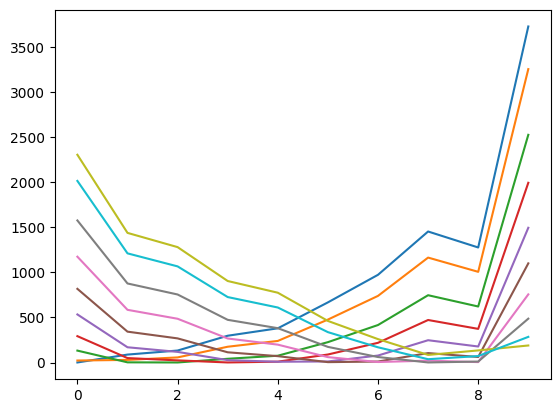

In [47]:
for i in range(len(x)):
    print('residu donnee '+str(i)+' = '+str(profil_residuel(x, y, i)))
    plt.plot(x, profil_residuel(x, y, i), '-', label=f'e{i}')
plt.show()

#### <span style="color:blue">REPONSE 4.2.b :</span> 

Le profil résiduel de la donnée aberrante est toujours plus grand que les autres, en particulier lorsqu'on ôte la donnée de la base d'apprentissage.

In [50]:
def cook(x, y, i):
    x_del_i = np.delete(x, i)
    y_del_i = np.delete(y, i)

    lr = LinearRegression()
    lri = LinearRegression()

    lr.fit(x[:, np.newaxis], y)
    lri.fit(x_del_i[:, np.newaxis], y_del_i)

    y_pred = lr.predict(x[:, np.newaxis])
    y_pred_i = lri.predict(x[i].reshape(1, -1))
    
    s_2 = s2(y, lr.predict(x[:, np.newaxis]))
    Di = ((y_pred_i-y_pred[i])**2) / (2 * s_2)
    return Di

#### <span style="color:blue">REPONSE 4.2.c :</span> 


In [51]:
#calcul de D_i pour chaque i
for i in range(len(x)):
    print('D_'+str(i)+' = '+str(cook(x, y, i)))

D_0 = [0.00113945]
D_1 = [0.03494353]
D_2 = [0.00032265]
D_3 = [0.0002204]
D_4 = [0.00176176]
D_5 = [0.0008818]
D_6 = [0.00177772]
D_7 = [0.00046392]
D_8 = [0.16195983]
D_9 = [0.66384846]


## Question Bonus

Pour un jeu de données de 20 observations obtenues avec un coefficient directeur $\beta_1$ de $0.2$, faire un test d'hypothèse pour vérifier que les données sont corrélées avec une confiance de 95%. 

On rappelle que sous les hypothèses suivantes : 
 * $\mathbb{E}[\epsilon_i] = 0$,
 * $\mathbb{V}[\epsilon_i] = \sigma^2$,
 * $\forall i \neq j, \: Cov(\epsilon_i, \epsilon_j) = 0$,
 
on a : 

* $\mathbb{E}[\hat{\beta_0}] = \beta_0$,
* $\mathbb{E}[\hat{\beta_1}] = \beta_1$,
* $\mathbb{V}[\hat{\beta_0}] = \sigma^2(\frac{1}{n} + \frac{\bar{x_n}^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2})$,
* $\mathbb{V}[\hat{\beta_1}] = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2}$

En faisant l'hypothèse supplémentaire que les erreurs suivent une loi normale, $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, on a :

* $\hat{\beta_1} \sim \mathcal{N}(\beta_1, \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2})$,
* $\frac{(n-2) \cdot s^2}{\sigma^2} \sim \mathcal{X}^2(n-2)$,
* $\hat{\beta_1}$ et $s^2$ indépendants,

où $s^2 = \frac{\sum_{i=1}^n \hat{\epsilon_i}^2}{n-2}$ est un estimateur non biaisé de $\sigma^2$.

On peut en déduire que:

$$ \frac{ \frac{ \hat{\beta_1}-\beta_1}{\sqrt{\frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x_n})^2}}}}{\sqrt{\frac{\frac{(n-2)s^2}{\sigma^2}}{n-2}}} = \frac{\hat{\beta_1}-\beta_1}{\frac{s}{\sqrt{\sum_{i=1}^n (x_i - \bar{x_n})^2}}} = T_n \sim T(n-2)$$ 

où $T(n-2)$ désigne la loi de Student à $n-2$ degrés de liberté, d'espérance nulle si $n-2 > 1$.

Tester l'hypothèse H_0 : $\beta_1 = 0$ en prenant un risque de 5%. 

In [ ]:
from scipy.stats import t


...